In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
from IPython.display import display
from matplotlib import patches as mpatches

from skarf import set_cache_dir
from skarf.covariance import load_spi_config_map
from arfcexp.skarf_utils import AVAILABLE_SKARF_FUNCS

In [2]:
project_root = Path(os.environ["PROJECT_ROOT"]).resolve()
score_result_root = project_root / "results/hcp_1200_homotopic_fc_parallel"
result_root = score_result_root

PARC_SIZE = 200
ANALYSIS_TAG = "networkblock-v2"
REDUCER = "mean"
USE_ABS = True
INCLUDE_SKARF_LAG1 = True
N_SUBJECTS = None
MAX_COMBOS = None
PYSPI_FUNCS = None  # None -> load every discovered PySPI estimator in the score run family.
SKARF_FUNCS = None  # None -> load every discovered skarf estimator in the score run family.

EMPIRICAL_REFERENCE_METHOD = "pyspi"
EMPIRICAL_REFERENCE_FUNC = "cov_EmpiricalCovariance"
EMPIRICAL_REFERENCE_LAG = 0
PLOT_ANALYSIS_LEVEL = "overall"
NETWORK_ANALYSIS_LEVEL = "network"

run_dirs = []

if not score_result_root.exists():
    raise FileNotFoundError(f"Score result root not found: {score_result_root}")


def _sub_tag(n_subjects):
    return f"subs-{n_subjects}" if n_subjects is not None else "subs-all"


def _combo_tag(max_combos):
    return f"max-{max_combos}" if max_combos is not None else "max-all"


def _run_family_prefix():
    return (
        f"parc-{PARC_SIZE}__analysis-{ANALYSIS_TAG}__reducer-{REDUCER}"
        f"__rankabs-{int(USE_ABS)}"
        f"__skarf-lag1-{int(INCLUDE_SKARF_LAG1)}"
        f"__{_sub_tag(N_SUBJECTS)}__{_combo_tag(MAX_COMBOS)}"
        "__reference-betweennetwork"
    )


SKARF_LAGS = [0, 1] if INCLUDE_SKARF_LAG1 else [0]
RUN_FAMILY_PREFIX = _run_family_prefix()


def _parse_run_dir(path):
    name = path.name
    if "__selector-" not in name or "__lag-" not in name:
        return None

    selector_part = name.split("__selector-", 1)[1]
    selector_prefix, lag_text = selector_part.rsplit("__lag-", 1)
    if "__" not in selector_prefix:
        return None
    method, func = selector_prefix.split("__", 1)

    try:
        lag = int(lag_text)
    except ValueError:
        return None

    return {
        "method": method,
        "func": func,
        "lag": lag,
        "run_dir": path,
    }


def _score_spec_requested(spec):
    if spec["method"] == "pyspi":
        return PYSPI_FUNCS is None or spec["func"] in PYSPI_FUNCS
    if spec["method"] == "skarf":
        if spec["lag"] not in SKARF_LAGS:
            return False
        return SKARF_FUNCS is None or spec["func"] in SKARF_FUNCS
    return False


def _expected_score_specs():
    expected = []
    if PYSPI_FUNCS is not None:
        expected.extend({"method": "pyspi", "func": func, "lag": 0} for func in PYSPI_FUNCS)
    if SKARF_FUNCS is not None:
        expected.extend(
            {"method": "skarf", "func": func, "lag": lag}
            for func in SKARF_FUNCS
            for lag in SKARF_LAGS
        )
    return expected


def _spec_sort_key(spec):
    return (spec["method"], spec["func"], spec["lag"])


def _run_choice_key(spec):
    return (
        spec["run_dir"].stat().st_mtime,
        spec["run_dir"].name,
    )

In [3]:
def _discover_run_specs(
    *,
    result_root,
    run_family_prefix,
    spec_requested,
    expected_specs,
    label,
):
    run_dir_glob = f"{run_family_prefix}__selector-*"

    discovered_specs = []
    for path in sorted(result_root.glob(run_dir_glob)):
        if not path.is_dir():
            continue
        spec = _parse_run_dir(path)
        if spec is not None and spec_requested(spec):
            discovered_specs.append(spec)

    if not discovered_specs:
        raise FileNotFoundError(
            f"No {label} result directories matched the requested run family. "
            f"Checked glob: {run_dir_glob}"
        )

    run_spec_map = {}
    duplicate_rows = []
    for spec in discovered_specs:
        key = (spec["method"], spec["func"], spec["lag"])
        current = run_spec_map.get(key)
        if current is None:
            run_spec_map[key] = spec
            continue

        if _run_choice_key(spec) >= _run_choice_key(current):
            kept = spec
            dropped = current
        else:
            kept = current
            dropped = spec

        run_spec_map[key] = kept
        duplicate_rows.append(
            {
                "method": spec["method"],
                "func": spec["func"],
                "lag": spec["lag"],
                "kept_run_dir": kept["run_dir"].name,
                "dropped_run_dir": dropped["run_dir"].name,
            }
        )

    run_specs = sorted(run_spec_map.values(), key=_spec_sort_key)
    duplicate_specs_df = pd.DataFrame(duplicate_rows)

    found_keys = {(spec["method"], spec["func"], spec["lag"]) for spec in run_specs}
    missing_rows = [
        {
            **spec,
            "run_dir": None,
            "status": "missing",
        }
        for spec in expected_specs
        if (spec["method"], spec["func"], spec["lag"]) not in found_keys
    ]

    load_status_rows = [
        {
            "method": spec["method"],
            "func": spec["func"],
            "lag": spec["lag"],
            "run_dir": spec["run_dir"].name,
            "status": "loaded",
        }
        for spec in run_specs
    ]
    load_status_rows.extend(missing_rows)
    load_status_df = (
        pd.DataFrame(load_status_rows)
        .sort_values(["method", "func", "lag", "status"])
        .reset_index(drop=True)
    )
    missing_specs_df = load_status_df.loc[load_status_df["status"] == "missing"].reset_index(drop=True)

    return {
        "run_dir_glob": run_dir_glob,
        "discovered_specs": discovered_specs,
        "run_specs": run_specs,
        "load_status_df": load_status_df,
        "missing_specs_df": missing_specs_df,
        "duplicate_specs_df": duplicate_specs_df,
    }


score_run_bundle = _discover_run_specs(
    result_root=score_result_root,
    run_family_prefix=RUN_FAMILY_PREFIX,
    spec_requested=_score_spec_requested,
    expected_specs=_expected_score_specs(),
    label="score",
)

discovered_specs = score_run_bundle["discovered_specs"]
run_specs = score_run_bundle["run_specs"]
run_dirs = [spec["run_dir"] for spec in run_specs]
duplicate_specs_df = score_run_bundle["duplicate_specs_df"]
load_status_df = score_run_bundle["load_status_df"]
missing_specs_df = score_run_bundle["missing_specs_df"]

print("Score result root:", score_result_root)
print("Requested run family:", RUN_FAMILY_PREFIX)
print("Discovered family directories:", len(discovered_specs))
print("Loaded estimator directories:", len(run_specs))
print("Collapsed duplicate directories:", len(duplicate_specs_df))
print("Example directory:", run_dirs[0])
if len(missing_specs_df) > 0:
    print("Missing estimator directories:", len(missing_specs_df))
    display(missing_specs_df.head(20))
if len(duplicate_specs_df) > 0:
    print("Duplicate estimator directories detected:", len(duplicate_specs_df))
    display(duplicate_specs_df.head(20))

Score result root: /home/aerkent/skarf-experiments/results/hcp_1200_homotopic_fc_parallel
Requested run family: parc-200__analysis-networkblock-v2__reducer-mean__rankabs-1__skarf-lag1-1__subs-all__max-all__reference-betweennetwork
Discovered family directories: 171
Loaded estimator directories: 171
Collapsed duplicate directories: 0
Example directory: /home/aerkent/skarf-experiments/results/hcp_1200_homotopic_fc_parallel/parc-200__analysis-networkblock-v2__reducer-mean__rankabs-1__skarf-lag1-1__subs-all__max-all__reference-betweennetwork__selector-pyspi__bary_euclidean_max__lag-0


In [4]:
def _safe_read_csv(path):
    if not path.exists():
        return None
    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        return None


def _load_run_family(run_specs):
    combo_frames = []
    excluded_frames = []
    method_summary_frames = []
    scores_frames = []

    for spec in run_specs:
        run_dir = spec["run_dir"]
        combo_path = run_dir / "combination_status.csv"
        excluded_path = run_dir / "excluded_combinations.csv"
        method_summary_path = run_dir / "method_homotopic_summary.csv"
        scores_path = run_dir / "subject_homotopic_scores.parquet"

        df = _safe_read_csv(combo_path)
        if df is not None:
            df["run_dir"] = run_dir.name
            combo_frames.append(df)

        df = _safe_read_csv(excluded_path)
        if df is not None:
            df["run_dir"] = run_dir.name
            excluded_frames.append(df)

        df = _safe_read_csv(method_summary_path)
        if df is not None:
            df["run_dir"] = run_dir.name
            method_summary_frames.append(df)

        if scores_path.exists():
            df = pd.read_parquet(scores_path)
            if len(df) > 0:
                df["run_dir"] = run_dir.name
                scores_frames.append(df)

    combo_df = pd.concat(combo_frames, ignore_index=True) if combo_frames else pd.DataFrame()
    excluded_df = pd.concat(excluded_frames, ignore_index=True) if excluded_frames else pd.DataFrame()
    method_summary_df = (
        pd.concat(method_summary_frames, ignore_index=True) if method_summary_frames else pd.DataFrame()
    )
    scores_df = pd.concat(scores_frames, ignore_index=True) if scores_frames else pd.DataFrame()
    return combo_df, excluded_df, method_summary_df, scores_df


def _dedupe_method_summary(df):
    if len(df) == 0:
        return df
    subset = ["combo_key"] if "combo_key" in df.columns else []
    if "analysis_level" in df.columns:
        subset.append("analysis_level")
    if "network" in df.columns:
        subset.append("network")
    if not subset:
        return df.reset_index(drop=True)
    return df.drop_duplicates(subset=subset, keep="last").reset_index(drop=True)


def _dedupe_scores(df):
    if len(df) == 0:
        return df
    subset = ["sub", "combo_key"] if {"sub", "combo_key"}.issubset(df.columns) else []
    if "analysis_level" in df.columns:
        subset.append("analysis_level")
    if "network" in df.columns:
        subset.append("network")
    if not subset:
        return df.reset_index(drop=True)
    return df.drop_duplicates(subset=subset, keep="last").reset_index(drop=True)


combo_df, excluded_df, method_summary_all_df, scores_all_df = _load_run_family(run_specs)
method_summary_all_df = _dedupe_method_summary(method_summary_all_df.copy())
scores_all_df = _dedupe_scores(scores_all_df.copy())

if len(combo_df) > 0 and "combo_key" in combo_df.columns:
    combo_df = combo_df.drop_duplicates(subset=["combo_key"], keep="last").reset_index(drop=True)
if len(excluded_df) > 0 and {"method", "func"}.issubset(excluded_df.columns):
    excluded_df = excluded_df.drop_duplicates(subset=["method", "func", "reason"], keep="last").reset_index(drop=True)

analysis_level_available = (
    len(scores_all_df) > 0
    and "analysis_level" in scores_all_df.columns
    and scores_all_df["analysis_level"].notna().any()
)
if analysis_level_available:
    scores_df = scores_all_df.loc[scores_all_df["analysis_level"] == PLOT_ANALYSIS_LEVEL].copy()
    network_scores_df = scores_all_df.loc[
        scores_all_df["analysis_level"] == NETWORK_ANALYSIS_LEVEL
    ].copy()
else:
    scores_df = scores_all_df.copy()
    network_scores_df = pd.DataFrame()

if len(method_summary_all_df) > 0 and "analysis_level" in method_summary_all_df.columns:
    method_summary_df = method_summary_all_df.loc[
        method_summary_all_df["analysis_level"] == PLOT_ANALYSIS_LEVEL
    ].copy()
    network_method_summary_df = method_summary_all_df.loc[
        method_summary_all_df["analysis_level"] == NETWORK_ANALYSIS_LEVEL
    ].copy()
else:
    method_summary_df = method_summary_all_df.copy()
    network_method_summary_df = pd.DataFrame()

empirical_reference_plot_df = scores_df.copy()
if len(empirical_reference_plot_df) > 0 and "network" in empirical_reference_plot_df.columns:
    empirical_reference_plot_df = empirical_reference_plot_df.loc[
        empirical_reference_plot_df["network"] == "all"
    ].copy()
if len(empirical_reference_plot_df) > 0:
    empirical_reference_plot_df = empirical_reference_plot_df.loc[
        (empirical_reference_plot_df["method"] == EMPIRICAL_REFERENCE_METHOD)
        & (empirical_reference_plot_df["func"] == EMPIRICAL_REFERENCE_FUNC)
        & (empirical_reference_plot_df["lag"].fillna(0).astype(int) == EMPIRICAL_REFERENCE_LAG)
    ].copy()

required_reference_cols = [
    "between_network_reference_mean",
    "between_network_reference_q25",
    "between_network_reference_q75",
]
empirical_reference_available = (
    len(empirical_reference_plot_df) > 0
    and set(required_reference_cols).issubset(empirical_reference_plot_df.columns)
    and all(
        np.isfinite(empirical_reference_plot_df[col].to_numpy(dtype=np.float64)).any()
        for col in required_reference_cols
    )
)
print("Selected analysis level:", PLOT_ANALYSIS_LEVEL)
print("Overall score rows:", len(scores_df))
print("Network score rows:", len(network_scores_df))
print("Empirical-covariance reference rows:", len(empirical_reference_plot_df))
print("Empirical-covariance between-network reference available:", bool(empirical_reference_available))

if len(scores_df) > 0:
    family_subject_df = (
        scores_df.dropna(subset=["homotopic_score"])
        .groupby(["sub", "method"], as_index=False)["homotopic_score"]
        .mean()
        .rename(columns={"homotopic_score": "family_mean_score"})
    )
else:
    family_subject_df = pd.DataFrame(columns=["sub", "method", "family_mean_score"])

combo_df.head()

Selected analysis level: overall
Overall score rows: 147390
Network score rows: 1031730
Empirical-covariance reference rows: 867
Empirical-covariance between-network reference available: True


,method,func,lag,combo_key,status,valid_fraction,n_subjects,n_valid_subjects,run_dir
0,pyspi,bary_euclidean_max,0,pyspi__bary_euclidean_max,ok,1.0,867,867,parc-200__analysis-networkblock-v2__reducer-me...
1,pyspi,ce_gaussian,0,pyspi__ce_gaussian,ok,1.0,867,867,parc-200__analysis-networkblock-v2__reducer-me...
2,pyspi,ce_kernel_W-0.5,0,pyspi__ce_kernel_W-0.5,ok,1.0,867,867,parc-200__analysis-networkblock-v2__reducer-me...
3,pyspi,cohmag_multitaper_max_fs-1_fmin-0-25_fmax-0-5,0,pyspi__cohmag_multitaper_max_fs-1_fmin-0-25_fm...,ok,1.0,867,867,parc-200__analysis-networkblock-v2__reducer-me...
4,pyspi,cohmag_multitaper_max_fs-1_fmin-0_fmax-0-25,0,pyspi__cohmag_multitaper_max_fs-1_fmin-0_fmax-...,ok,1.0,867,867,parc-200__analysis-networkblock-v2__reducer-me...


In [5]:
print("Requested run family:", RUN_FAMILY_PREFIX)
print("Discovered family directories:", len(discovered_specs))
print("Loaded estimator directories:", int((load_status_df["status"] == "loaded").sum()))
print("Missing estimator directories:", int((load_status_df["status"] == "missing").sum()))
print("Duplicate estimator directories collapsed:", len(duplicate_specs_df))

if len(missing_specs_df) > 0:
    print("Missing estimator directory examples:")
    display(missing_specs_df.head(20))
if len(duplicate_specs_df) > 0:
    print("Duplicate estimator directory examples:")
    display(duplicate_specs_df.head(20))

print("Total combinations evaluated:", len(combo_df))
if "status" in combo_df.columns:
    print("Combinations with sufficient data:", int((combo_df["status"] == "ok").sum()))
else:
    print("Combinations with sufficient data: unavailable (missing status column)")

print("Excluded combinations:", len(excluded_df))
print("Excluded reasons:")
if len(excluded_df) > 0 and "reason" in excluded_df.columns:
    print(excluded_df["reason"].value_counts(dropna=False))
else:
    print("None")

display(load_status_df.groupby(["method", "status"]).size().rename("n").reset_index())

if len(combo_df) > 0 and {"method", "status"}.issubset(combo_df.columns):
    display(combo_df.groupby(["method", "status"]).size().rename("n").reset_index())

Requested run family: parc-200__analysis-networkblock-v2__reducer-mean__rankabs-1__skarf-lag1-1__subs-all__max-all__reference-betweennetwork
Discovered family directories: 171
Loaded estimator directories: 171
Missing estimator directories: 0
Duplicate estimator directories collapsed: 0
Total combinations evaluated: 171
Combinations with sufficient data: 170
Excluded combinations: 2
Excluded reasons:
reason
degenerate_matrix    2
Name: count, dtype: int64


,method,status,n
0,pyspi,loaded,147
1,skarf,loaded,24


,method,status,n
0,pyspi,insufficient_data,1
1,pyspi,ok,146
2,skarf,ok,24


In [6]:
def _cohen_d_paired(x, y):
    diff = np.asarray(x, dtype=np.float64) - np.asarray(y, dtype=np.float64)
    sd = np.std(diff, ddof=1)
    if not np.isfinite(sd) or sd <= 0:
        return np.nan
    return float(np.mean(diff) / sd)


def _cohen_d_independent(x, y):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    vx = np.var(x, ddof=1)
    vy = np.var(y, ddof=1)
    pooled = ((nx - 1) * vx + (ny - 1) * vy) / (nx + ny - 2)
    if not np.isfinite(pooled) or pooled <= 0:
        return np.nan
    return float((np.mean(x) - np.mean(y)) / np.sqrt(pooled))


def _cliffs_delta(x, y):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    if len(x) == 0 or len(y) == 0:
        return np.nan
    cmp = np.subtract.outer(x, y)
    n_pos = int(np.sum(cmp > 0))
    n_neg = int(np.sum(cmp < 0))
    return float((n_pos - n_neg) / (len(x) * len(y)))


stats_summary = {
    "family_subject_test": None,
    "method_distribution_test": None,
    "skarf_lag_test": None,
}

if len(family_subject_df) > 0:
    pivot = family_subject_df.pivot(index="sub", columns="method", values="family_mean_score")
    if {"pyspi", "skarf"}.issubset(set(pivot.columns)):
        paired = pivot[["pyspi", "skarf"]].dropna()
        if len(paired) > 0:
            py = paired["pyspi"].to_numpy(dtype=np.float64)
            sk = paired["skarf"].to_numpy(dtype=np.float64)
            test = stats.wilcoxon(py, sk, alternative="two-sided")
            stats_summary["family_subject_test"] = {
                "n": int(len(paired)),
                "wilcoxon_stat": float(test.statistic),
                "pvalue": float(test.pvalue),
                "mean_pyspi": float(np.mean(py)),
                "mean_skarf": float(np.mean(sk)),
                "mean_diff_pyspi_minus_skarf": float(np.mean(py - sk)),
                "cohen_dz": float(_cohen_d_paired(py, sk)),
            }

if len(method_summary_df) > 0:
    py = method_summary_df.loc[method_summary_df["method"] == "pyspi", "mean"].dropna().to_numpy(dtype=np.float64)
    sk = method_summary_df.loc[method_summary_df["method"] == "skarf", "mean"].dropna().to_numpy(dtype=np.float64)
    if len(py) > 0 and len(sk) > 0:
        test = stats.mannwhitneyu(py, sk, alternative="two-sided")
        stats_summary["method_distribution_test"] = {
            "n_pyspi": int(len(py)),
            "n_skarf": int(len(sk)),
            "mannwhitney_u": float(test.statistic),
            "pvalue": float(test.pvalue),
            "mean_pyspi": float(np.mean(py)),
            "mean_skarf": float(np.mean(sk)),
            "cohen_d": float(_cohen_d_independent(py, sk)),
            "cliffs_delta": float(_cliffs_delta(py, sk)),
        }

    skarf_summary_df = method_summary_df.query("method == 'skarf'").copy()
    if len(skarf_summary_df) > 0:
        lag_pivot = skarf_summary_df.pivot(index="func", columns="lag", values="mean")
        if {0, 1}.issubset(set(lag_pivot.columns)):
            lag_pairs = lag_pivot[[0, 1]].dropna()
            if len(lag_pairs) > 0:
                lag0 = lag_pairs[0].to_numpy(dtype=np.float64)
                lag1 = lag_pairs[1].to_numpy(dtype=np.float64)
                test = stats.wilcoxon(lag0, lag1, alternative="two-sided")
                stats_summary["skarf_lag_test"] = {
                    "n": int(len(lag_pairs)),
                    "wilcoxon_stat": float(test.statistic),
                    "pvalue": float(test.pvalue),
                    "mean_lag0": float(np.mean(lag0)),
                    "mean_lag1": float(np.mean(lag1)),
                    "cohen_dz": float(_cohen_d_paired(lag0, lag1)),
                }

stats_summary

{'family_subject_test': {'n': 867,
  'wilcoxon_stat': 0.0,
  'pvalue': 1.6339286643398067e-143,
  'mean_pyspi': 0.5040980269892897,
  'mean_skarf': 0.5717218269908791,
  'mean_diff_pyspi_minus_skarf': -0.06762380000158938,
  'cohen_dz': -8.63846048073356},
 'method_distribution_test': {'n_pyspi': 146,
  'n_skarf': 24,
  'mannwhitney_u': 858.0,
  'pvalue': 6.372343934791921e-05,
  'mean_pyspi': 0.5040980269892897,
  'mean_skarf': 0.5717218269908791,
  'cohen_d': -0.7354178559758616,
  'cliffs_delta': -0.5102739726027398},
 'skarf_lag_test': {'n': 12,
  'wilcoxon_stat': 36.0,
  'pvalue': 0.85009765625,
  'mean_lag0': 0.5703213939484405,
  'mean_lag1': 0.5731222600333179,
  'cohen_dz': -0.23711007289800767}}

,n,wilcoxon_stat,pvalue,mean_pyspi,mean_skarf,mean_diff_pyspi_minus_skarf,cohen_dz
0,867,0.0,1.633929e-143,0.504098,0.571722,-0.067624,-8.63846


Paired subjects: 867


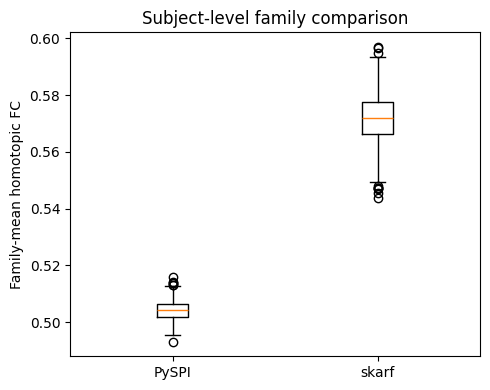

In [7]:
pivot = family_subject_df.pivot(index='sub', columns='method', values='family_mean_score')
required = {'pyspi', 'skarf'}

display(pd.DataFrame(stats_summary.get('family_subject_test') or {}, index=[0]))

if required.issubset(set(pivot.columns)):
    paired = pivot[['pyspi', 'skarf']].dropna()
    print('Paired subjects:', len(paired))

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.boxplot([paired['pyspi'], paired['skarf']], tick_labels=['PySPI', 'skarf'])
    ax.set_ylabel('Family-mean homotopic FC')
    ax.set_title('Subject-level family comparison')
    plt.tight_layout()
else:
    print('Family comparison plot skipped: both PySPI and skarf are required.')
    print('Available method columns:', sorted(map(str, pivot.columns)))

,n_pyspi,n_skarf,mannwhitney_u,pvalue,mean_pyspi,mean_skarf,cohen_d,cliffs_delta
0,146,24,858.0,0.000064,0.504098,0.571722,-0.735418,-0.510274


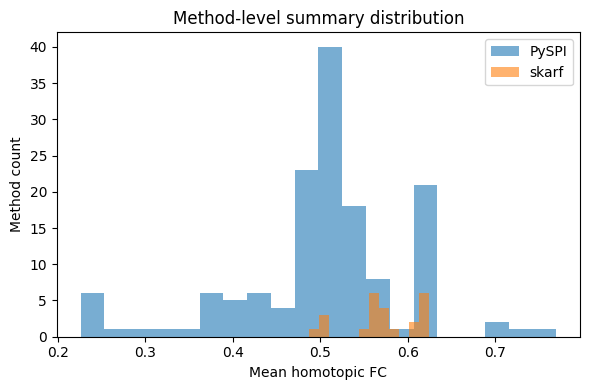

In [8]:
display(pd.DataFrame(stats_summary.get('method_distribution_test', {}), index=[0]))

fig, ax = plt.subplots(figsize=(6, 4))
py = method_summary_df.loc[method_summary_df['method'] == 'pyspi', 'mean'].dropna()
sk = method_summary_df.loc[method_summary_df['method'] == 'skarf', 'mean'].dropna()
ax.hist(py, bins=20, alpha=0.6, label='PySPI')
ax.hist(sk, bins=12, alpha=0.6, label='skarf')
ax.set_xlabel('Mean homotopic FC')
ax.set_ylabel('Method count')
ax.legend()
ax.set_title('Method-level summary distribution')
plt.tight_layout()

,n,wilcoxon_stat,pvalue,mean_lag0,mean_lag1,cohen_dz
0,12,36.0,0.850098,0.570321,0.573122,-0.23711


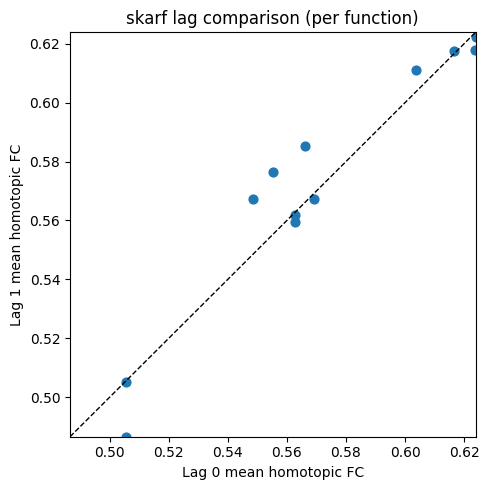

In [9]:
display(pd.DataFrame(stats_summary.get('skarf_lag_test') or {}, index=[0]))

skarf = method_summary_df.query("method == 'skarf'").copy()
lag_pivot = skarf.pivot(index='func', columns='lag', values='mean')

if {0, 1}.issubset(set(lag_pivot.columns)):
    lag_pivot = lag_pivot[[0, 1]].dropna()
    if len(lag_pivot) == 0:
        print('No skarf functions have both lag-0 and lag-1 summaries.')
    else:
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.scatter(lag_pivot[0], lag_pivot[1], s=40)
        lims = [
            min(lag_pivot[0].min(), lag_pivot[1].min()),
            max(lag_pivot[0].max(), lag_pivot[1].max()),
        ]
        ax.plot(lims, lims, '--', color='k', linewidth=1)
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_xlabel('Lag 0 mean homotopic FC')
        ax.set_ylabel('Lag 1 mean homotopic FC')
        ax.set_title('skarf lag comparison (per function)')
        plt.tight_layout()
else:
    print('Lag scatter skipped: both lag-0 and lag-1 columns are required.')
    print('Available lag columns:', sorted(map(str, lag_pivot.columns)))

In [10]:
top_py = method_summary_df.query("method == 'pyspi'").nlargest(10, 'mean')[['func', 'lag', 'mean', 'median']]
top_sk = method_summary_df.query("method == 'skarf'").nlargest(10, 'mean')[['func', 'lag', 'mean', 'median']]

print('Top 10 PySPI methods by mean homotopic FC')
display(top_py)

print('Top 10 skarf methods by mean homotopic FC')
display(top_sk)

Top 10 PySPI methods by mean homotopic FC


,func,lag,mean,median
479,lcss_constraint-sakoe-chiba,0,0.769527,0.771087
7,bary_euclidean_max,0,0.726061,0.727099
1151,xcorr_max_sig-True,0,0.701650,0.702292
471,lcss,0,0.698804,0.699743
183,cov_GraphicalLassoCV,0,0.630620,0.631510
519,mi_gaussian,0,0.628405,0.629400
215,cov_ShrunkCovariance,0,0.627058,0.627565
175,cov_EmpiricalCovariance,0,0.627058,0.627565
207,cov_OAS,0,0.627050,0.627575
191,cov_LedoitWolf,0,0.627048,0.627568


Top 10 skarf methods by mean homotopic FC


,func,lag,mean,median
1303,linear_pls,0,0.623867,0.623878
1287,linear_pca-ridge,0,0.623733,0.624337
1311,linear_pls,1,0.622185,0.623158
1295,linear_pca-ridge,1,0.617837,0.618008
1199,cov_graphicallasso,1,0.617664,0.618196
1191,cov_graphicallasso,0,0.616477,0.616647
1183,cov_empirical,1,0.611125,0.613270
1175,cov_empirical,0,0.603795,0.605679
1327,linear_ridge,1,0.585111,0.585691
1231,linear_enet-pos,1,0.576387,0.576313


## Poster-style Box Plots

In [11]:
PROJECT_ROOT = Path(os.environ["PROJECT_ROOT"]).resolve()
STYLE_PATH = os.environ["MPL_STYLE"]
plt.style.use(STYLE_PATH)

PLOTW, PLOTH = plt.rcParams["figure.figsize"]
FORMAT = plt.rcParams["savefig.format"]
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

TOPK_PYSPI_PER_NARROW_CATEGORY = 2
MAX_SKARF_FUNCS = 12
LAG_ORDER = [0, 1]
LAG_STYLES = {
    0: {"alpha": 0.85, "hatch": ""},
    1: {"alpha": 0.45, "hatch": "//"},
}
REFERENCE_BAND_COLOR = "#6c757d"
EMPIRICAL_COV_BAND_COLOR = "#d95f02"
REFERENCE_BAND_ALPHA = 0.42
EMPIRICAL_COV_BAND_ALPHA = 0.22


def add_iqr_band(
    ax,
    q25: float,
    q75: float,
    color: str,
    alpha: float = 0.2,
    label: str | None = None,
):
    if not (np.isfinite(q25) and np.isfinite(q75)):
        return None
    span = ax.axhspan(q25, q75, color=color, alpha=alpha, zorder=0.1, linewidth=0)
    if label:
        span.set_label(label)
    return span


def get_significance(pvalue: float) -> int:
    if pvalue < 0.001:
        return 3
    if pvalue < 0.01:
        return 2
    if pvalue < 0.05:
        return 1
    return 0


def format_label(
    base_label: str,
    values: np.ndarray,
    reference_p: float,
    baseline_p: float,
    bonferroni_factor: int,
    baseline_score: float,
) -> str:
    reference_sig = get_significance(reference_p * bonferroni_factor)
    if not reference_sig:
        prefix = "(·)"
    else:
        baseline_sig = get_significance(baseline_p * bonferroni_factor)
        if baseline_sig:
            prefix = "(<)" if np.median(values) < baseline_score else "(>)"
        else:
            prefix = "(~)"
    return f"{prefix} {base_label}"


def _safe_mwu_pvalue(x: np.ndarray, y: np.ndarray, alternative: str) -> float:
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    if len(x) == 0 or len(y) == 0:
        return 1.0
    return float(stats.mannwhitneyu(x, y, alternative=alternative).pvalue)


required_cols = {
    "sub",
    "method",
    "func",
    "lag",
    "homotopic_score",
    "between_network_reference_mean",
    "between_network_reference_q25",
    "between_network_reference_q75",
}
if not required_cols.issubset(scores_df.columns):
    missing = sorted(required_cols.difference(scores_df.columns))
    raise KeyError(f"scores_df is missing required columns: {missing}")
if len(scores_df) == 0:
    raise ValueError("No overall homotopic scores available for plotting.")
if not empirical_reference_available:
    raise ValueError(
        "Empirical covariance between-network reference is missing or has no populated summaries. "
        "Run the network-block homotopy benchmark for pyspi/cov_EmpiricalCovariance."
    )

plot_df = scores_df.dropna(subset=["homotopic_score"]).copy()
plot_df["func"] = plot_df["func"].astype(str)
plot_df["lag"] = plot_df["lag"].fillna(0).astype(int)

if len(plot_df) == 0:
    raise ValueError("No non-null homotopic scores available for plotting.")

score_col = "homotopic_score"
score_min = float(np.nanmin(plot_df[score_col]))
score_max = float(np.nanmax(plot_df[score_col]))
print("Using ranked homotopic mean scores directly (no normalization).")
print("Using overall network-average rows for summaries and poster plots.")
print(f"Score range: [{score_min:.3f}, {score_max:.3f}]")

if score_min < -1e-6 or score_max > 1 + 1e-6:
    raise ValueError(
        "Detected homotopic_score values outside [0, 1]. "
        "This usually means legacy absolute-scale outputs were loaded instead of rank-based outputs."
    )

emp_cov_df = plot_df.loc[
    (plot_df["method"] == "pyspi")
    & (plot_df["func"] == "cov_EmpiricalCovariance")
    & (plot_df["lag"] == 0),
    score_col,
].to_numpy(dtype=np.float64)
emp_cov_df = emp_cov_df[np.isfinite(emp_cov_df)]
if len(emp_cov_df) == 0:
    raise ValueError(
        "Empirical covariance baseline missing (expected pyspi/cov_EmpiricalCovariance lag=0 rows)."
    )
emp_cov_q25, emp_cov_q75 = np.nanpercentile(emp_cov_df, [25, 75])
emp_cov_median = float(np.nanmedian(emp_cov_df))

empirical_reference_values = empirical_reference_plot_df[
    "between_network_reference_mean"
].to_numpy(dtype=np.float64)
empirical_reference_values = empirical_reference_values[np.isfinite(empirical_reference_values)]
if len(empirical_reference_values) == 0:
    raise ValueError(
        "Empirical covariance reference rows are present, but between_network_reference_mean is empty."
    )
empirical_reference_q25, empirical_reference_q75 = np.nanpercentile(
    empirical_reference_values,
    [25, 75],
)
if not (np.isfinite(empirical_reference_q25) and np.isfinite(empirical_reference_q75)):
    raise ValueError("Could not compute a finite shared empirical-covariance reference IQR band.")
print("Using shared empirical-covariance between-network reference-score IQR across subjects.")
print(f"Shared reference-score IQR: [{empirical_reference_q25:.3f}, {empirical_reference_q75:.3f}]")

has_directional = {"homotopic_score_upper", "homotopic_score_lower"}.issubset(plot_df.columns)
if has_directional:
    directional_valid = (
        np.isfinite(plot_df["homotopic_score_upper"]).any()
        and np.isfinite(plot_df["homotopic_score_lower"]).any()
    )
    if directional_valid:
        directional_summary = (
            plot_df.groupby(["method", "func", "lag"], as_index=False)[
                ["homotopic_score_upper", "homotopic_score_lower"]
            ]
            .median()
            .sort_values(["method", "func", "lag"])
        )
        print("Directional median summaries are available.")
        with pd.option_context("display.max_rows", None, "display.max_columns", None):
            display(directional_summary[directional_summary["homotopic_score_lower"].notna()])

Using ranked homotopic mean scores directly (no normalization).
Using overall network-average rows for summaries and poster plots.
Score range: [0.188, 0.811]
Using shared empirical-covariance between-network reference-score IQR across subjects.
Shared reference-score IQR: [0.460, 0.465]
Directional median summaries are available.


,method,func,lag,homotopic_score_upper,homotopic_score_lower
2,pyspi,ce_kernel_W-0.5,0,0.389065,0.388447
43,pyspi,gc_gaussian_k-1_kt-1_l-1_lt-1,0,0.517188,0.516078
44,pyspi,gd_multitaper_delay_fs-1_fmin-0-25_fmax-0-5,0,0.493443,0.493443
45,pyspi,gd_multitaper_delay_fs-1_fmin-0_fmax-0-25,0,0.439171,0.439171
46,pyspi,gd_multitaper_delay_fs-1_fmin-0_fmax-0-5,0,0.527719,0.527719
78,pyspi,phase_multitaper_max_fs-1_fmin-0-25_fmax-0-5,0,0.391751,0.392265
79,pyspi,phase_multitaper_max_fs-1_fmin-0_fmax-0-25,0,0.297432,0.296802
80,pyspi,phase_multitaper_max_fs-1_fmin-0_fmax-0-5,0,0.315126,0.316356
81,pyspi,phase_multitaper_mean_fs-1_fmin-0-25_fmax-0-5,0,0.451017,0.451017
82,pyspi,phase_multitaper_mean_fs-1_fmin-0_fmax-0-25,0,0.422567,0.423204


In [12]:
pyspi_df = plot_df.query("method == 'pyspi'").copy()
spi_list_dir = PROJECT_ROOT / "resources/spi_lists"
set_cache_dir(spi_list_dir)
spi_config_map, _ = load_spi_config_map()
spi_list = (spi_list_dir / "spi_list_select_300s_149.txt").read_text().strip().split()
spi_id_map = {spi: idx for idx, spi in enumerate(spi_list, start=1)}

spi_table = pd.DataFrame.from_records(
    [
        {
            "spi": spi,
            "category": config["module_name"].split(".")[-1],
            "identifier": spi.split("_")[0],
        }
        for spi, config in spi_config_map.items()
        if spi in spi_list
    ]
)
spi_table["spi"] = pd.Categorical(spi_table["spi"], categories=spi_list, ordered=True)
category_levels = sorted(spi_table["category"].unique())
spi_table["category"] = pd.Categorical(
    spi_table["category"],
    categories=category_levels,
    ordered=True,
)
identifier_levels = [identifier for identifier in spi_table["identifier"].unique()]
spi_table["identifier"] = pd.Categorical(
    spi_table["identifier"],
    categories=identifier_levels,
    ordered=True,
)

pyspi_category_colors = {
    category: color_cycle[ii % len(color_cycle)]
    for ii, category in enumerate(category_levels)
}

pyspi_with_meta = spi_table.merge(
    pyspi_df.rename(columns={"func": "spi"}),
    on="spi",
    how="right",
)
pyspi_with_meta = pyspi_with_meta.dropna(subset=["spi"])
pyspi_with_meta["category"] = pd.Categorical(
    pyspi_with_meta["category"],
    categories=category_levels,
    ordered=True,
)
pyspi_with_meta["identifier"] = pd.Categorical(
    pyspi_with_meta["identifier"],
    categories=identifier_levels,
    ordered=True,
)

pyspi_values = (
    pyspi_with_meta.groupby(["category", "identifier", "spi"], as_index=False, observed=True)[score_col]
    .apply(lambda vals: vals.to_numpy(dtype=np.float64))
    .rename(columns={score_col: "values"})
)
pyspi_values["values"] = pyspi_values["values"].apply(lambda arr: arr[np.isfinite(arr)])
pyspi_values["median_score"] = pyspi_values["values"].apply(
    lambda arr: np.median(arr) if len(arr) else np.nan
)
pyspi_values = pyspi_values.sort_values(
    ["category", "identifier", "median_score"],
    ascending=[True, True, False],
)

pyspi_top_df = (
    pyspi_values.groupby(["category", "identifier"], as_index=False, group_keys=False, observed=True)
    .head(TOPK_PYSPI_PER_NARROW_CATEGORY)
    .reset_index(drop=True)
)
pyspi_funcs = pyspi_top_df["spi"].tolist()
pyspi_categories = [category for category in category_levels if category in set(pyspi_top_df["category"])]
pyspi_func_to_category = dict(zip(pyspi_top_df["spi"], pyspi_top_df["category"]))

pyspi_test_count = max(len(pyspi_funcs), 1)
pyspi_signif_labels = {}
for spi in pyspi_funcs:
    vals = pyspi_with_meta.loc[pyspi_with_meta["spi"] == spi, score_col].to_numpy(dtype=np.float64)
    reference_p = _safe_mwu_pvalue(vals, empirical_reference_values, alternative="greater")
    baseline_p = _safe_mwu_pvalue(vals, emp_cov_df, alternative="two-sided")
    base_label = f"{spi_id_map.get(spi, 0):03d} {spi[:20]}"
    pyspi_signif_labels[spi] = format_label(
        base_label,
        vals[np.isfinite(vals)],
        reference_p,
        baseline_p,
        pyspi_test_count,
        emp_cov_median,
    )

with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(pyspi_top_df)

,category,identifier,spi,values,median_score
0,basic,cov,cov_GraphicalLassoCV,"[0.6294118306396154, 0.5879324033048912, 0.605...",0.631510
1,basic,cov,cov_OAS,"[0.6226673946532044, 0.6023722069358637, 0.603...",0.627575
2,basic,prec,prec_GraphicalLassoCV,"[0.5843343401258884, 0.5729835884277744, 0.563...",0.579932
3,basic,prec,prec_ShrunkCovariance,"[0.5749522456513977, 0.5718241778510808, 0.546...",0.562487
4,basic,spearmanr,spearmanr,"[0.6202054570049123, 0.603310119049499, 0.6027...",0.627077
5,basic,kendalltau,kendalltau,"[0.6204078276553213, 0.6035977828595339, 0.602...",0.627503
6,basic,xcorr,xcorr_max_sig-True,"[0.7133115247497955, 0.6721481912413741, 0.684...",0.702292
7,basic,xcorr,xcorr_mean_sig-True,"[0.6209036556989037, 0.6091552113192487, 0.585...",0.611648
8,causal,reci,reci,"[0.41355665974646055, 0.4274702457078946, 0.44...",0.413944
9,distance,pdist,pdist_chebyshev,"[0.23857149972221808, 0.2500412153523777, 0.24...",0.252026


In [13]:
func_categories = {
    "cov": ["cov_empirical", "cov_graphicallasso"],
    "prec": ["prec_empirical", "prec_graphicallasso"],
    "lstsq": ["linear_ols", "linear_ridge"],
    "sparse": ["linear_lasso", "linear_enet"],
    "sparse-pos": ["linear_lasso-pos", "linear_enet-pos"],
    "lowrank": ["linear_pls", "linear_pca-ridge"],
}
func_category_map = {
    func: category for category, funcs in func_categories.items() for func in funcs
}
func_display_names = {
    "cov_empirical": "cov_emp",
    "cov_graphicallasso": "cov_glasso",
    "prec_empirical": "prec_emp",
    "prec_graphicallasso": "prec_glasso",
    "linear_ols": "lstsq_ols",
    "linear_ridge": "lstsq_ridge",
    "linear_lasso": "sparse_lasso",
    "linear_enet": "sparse_enet",
    "linear_lasso-pos": "sparse-pos_lasso",
    "linear_enet-pos": "sparse-pos_enet",
    "linear_pls": "lowrank_pls",
    "linear_pca-ridge": "lowrank_pca-ridge",
}
skarf_category_colors_all = {
    category: color_cycle[ii % len(color_cycle)]
    for ii, category in enumerate(func_categories.keys())
}

skarf_df = plot_df.query("method == 'skarf'").copy()
skarf_df["category"] = skarf_df["func"].map(func_category_map).fillna(
    skarf_df["func"].str.split("_").str[0]
)

skarf_combo_rank = (
    skarf_df.groupby(["func", "lag", "category"], as_index=False)[score_col]
    .median()
    .rename(columns={score_col: "median_score"})
)

skarf_func_rank = (
    skarf_combo_rank.groupby(["func", "category"], as_index=False)["median_score"]
    .max()
)
skarf_func_rank["category"] = pd.Categorical(
    skarf_func_rank["category"],
    categories=list(func_categories.keys()),
    ordered=True,
)
poster_skarf_order = [func for func in AVAILABLE_SKARF_FUNCS if func in set(skarf_func_rank["func"])]
skarf_func_order = poster_skarf_order[:MAX_SKARF_FUNCS]

skarf_categories = [
    category
    for category in func_categories.keys()
    if category in set(pd.Series([func_category_map.get(func, "unknown") for func in skarf_func_order]))
]
skarf_category_colors = {category: skarf_category_colors_all[category] for category in skarf_categories}

with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(
        skarf_combo_rank[skarf_combo_rank["func"].isin(skarf_func_order)]
        .sort_values(["category", "func", "lag"])
        .reset_index(drop=True)
    )

,func,lag,category,median_score
0,cov_empirical,0,cov,0.605679
1,cov_empirical,1,cov,0.613270
2,cov_graphicallasso,0,cov,0.616647
3,cov_graphicallasso,1,cov,0.618196
4,linear_pca-ridge,0,lowrank,0.624337
5,linear_pca-ridge,1,lowrank,0.618008
6,linear_pls,0,lowrank,0.623878
7,linear_pls,1,lowrank,0.623158
8,linear_ols,0,lstsq,0.505645
9,linear_ols,1,lstsq,0.486097


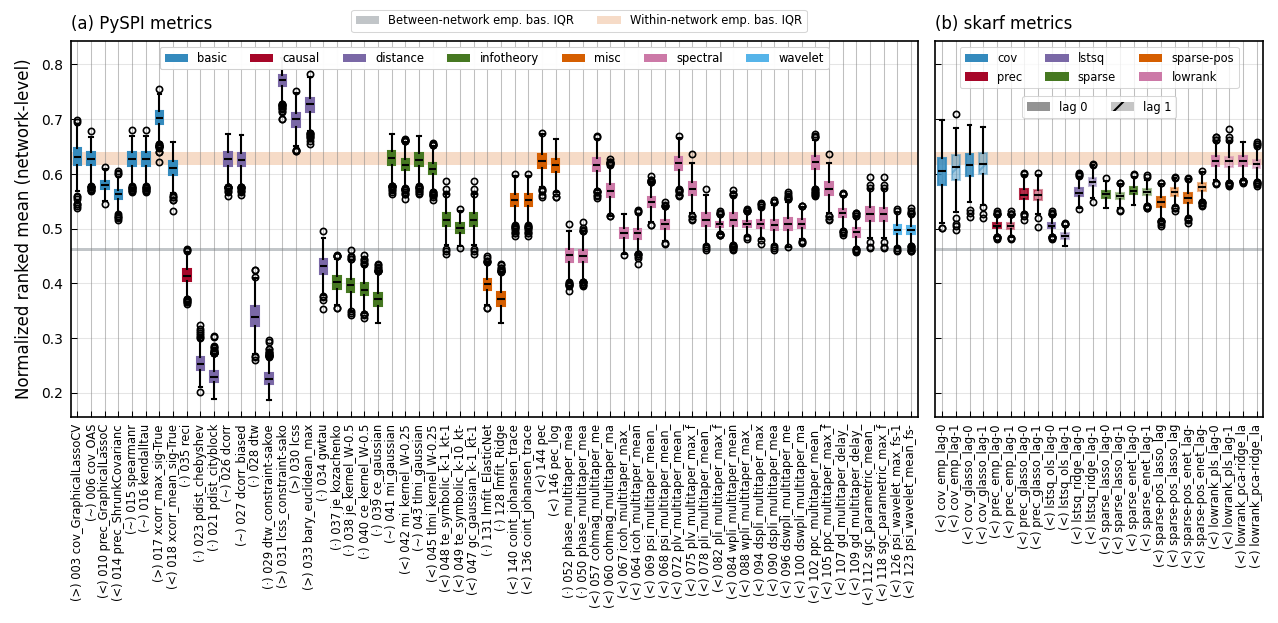

In [14]:
left_width = max(len(pyspi_funcs), 1)
right_width = max(len(skarf_func_order) * len(LAG_ORDER), 1)
fig, axes = plt.subplots(
    1,
    2,
    figsize=(3 * PLOTW, 0.95 * PLOTW),
    gridspec_kw={"width_ratios": [left_width, right_width]},
    sharey=True,
)

ax = axes[0]
reference_handle = add_iqr_band(
    ax,
    empirical_reference_q25,
    empirical_reference_q75,
    REFERENCE_BAND_COLOR,
    REFERENCE_BAND_ALPHA,
    label="Between-network emp. bas. IQR",
)
emp_handle = add_iqr_band(
    ax,
    emp_cov_q25,
    emp_cov_q75,
    EMPIRICAL_COV_BAND_COLOR,
    EMPIRICAL_COV_BAND_ALPHA,
    label="Within-network emp. bas. IQR",
)

if pyspi_funcs:
    pyspi_positions = np.arange(len(pyspi_funcs), dtype=np.float64)
    pyspi_data = [
        pyspi_with_meta.loc[pyspi_with_meta["spi"] == spi, score_col].to_numpy(dtype=np.float64)
        for spi in pyspi_funcs
    ]
    pyspi_box = ax.boxplot(
        pyspi_data,
        positions=pyspi_positions,
        widths=0.55,
        patch_artist=True,
        medianprops={"color": "k"},
    )
    for spi, patch in zip(pyspi_funcs, pyspi_box["boxes"]):
        category = pyspi_func_to_category[spi]
        color = pyspi_category_colors.get(category, "#999999")
        patch.set_facecolor(color)
        patch.set_edgecolor(color)

    pyspi_labels = [pyspi_signif_labels.get(spi, spi[:20]) for spi in pyspi_funcs]
    ax.set_xticks(pyspi_positions)
    ax.set_xticklabels(pyspi_labels, rotation=90, fontsize="x-small")
else:
    ax.set_xticks([])

ax.set_title("(a) PySPI metrics", loc="left", fontsize="medium")
ax.set_ylabel("Normalized ranked mean (network-level)", fontsize="medium")

ref_handles = [handle for handle in [reference_handle, emp_handle] if handle is not None]
if ref_handles:
    ref_legend = ax.legend(
        handles=ref_handles,
        loc="upper center",
        bbox_to_anchor=(0.6, 1.1),
        ncol=len(ref_handles),
        fontsize="x-small",
    )
    ax.add_artist(ref_legend)

pyspi_cat_handles = [
    mpatches.Patch(facecolor=pyspi_category_colors[category], edgecolor="none", label=category)
    for category in pyspi_categories
]
if pyspi_cat_handles:
    cat_legend = ax.legend(
        handles=pyspi_cat_handles,
        loc="upper center",
        ncol=max(len(pyspi_cat_handles), 1),
        fontsize="x-small",
    )
    ax.add_artist(cat_legend)

ax = axes[1]
add_iqr_band(
    ax,
    empirical_reference_q25,
    empirical_reference_q75,
    REFERENCE_BAND_COLOR,
    REFERENCE_BAND_ALPHA,
)
add_iqr_band(
    ax,
    emp_cov_q25,
    emp_cov_q75,
    EMPIRICAL_COV_BAND_COLOR,
    EMPIRICAL_COV_BAND_ALPHA,
)

if skarf_func_order:
    combo_positions = {}
    xtick_positions = []
    xtick_labels = []

    skarf_test_count = max(len(skarf_func_order) * len(LAG_ORDER), 1)

    for func_idx, func in enumerate(skarf_func_order):
        for lag_idx, lag in enumerate(LAG_ORDER):
            pos = func_idx * len(LAG_ORDER) + lag_idx
            combo_positions[(func, lag)] = pos
            xtick_positions.append(pos)

            vals = skarf_df.loc[
                (skarf_df["func"] == func) & (skarf_df["lag"] == lag),
                score_col,
            ].to_numpy(dtype=np.float64)
            reference_p = _safe_mwu_pvalue(vals, empirical_reference_values, alternative="greater")
            baseline_p = _safe_mwu_pvalue(vals, emp_cov_df, alternative="two-sided")
            base = f"{func_display_names.get(func, func)}_lag-{lag}"[:20]
            xtick_labels.append(
                format_label(
                    base,
                    vals[np.isfinite(vals)],
                    reference_p,
                    baseline_p,
                    skarf_test_count,
                    emp_cov_median,
                )
            )

    for lag in LAG_ORDER:
        lag_positions = np.array([combo_positions[(func, lag)] for func in skarf_func_order], dtype=np.float64)
        lag_data = []

        for func in skarf_func_order:
            vals = skarf_df.loc[
                (skarf_df["func"] == func) & (skarf_df["lag"] == lag),
                score_col,
            ].to_numpy(dtype=np.float64)
            lag_data.append(vals if len(vals) else np.array([np.nan]))

        box = ax.boxplot(
            lag_data,
            positions=lag_positions,
            widths=0.55,
            patch_artist=True,
            medianprops={"color": "k"},
        )

        for func, patch in zip(skarf_func_order, box["boxes"]):
            category = func_category_map.get(func, "unknown")
            color = skarf_category_colors.get(category, "#999999")
            patch.set_facecolor(color)
            patch.set_edgecolor(color)
            patch.set_alpha(LAG_STYLES[lag]["alpha"])
            patch.set_hatch(LAG_STYLES[lag]["hatch"])

    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels, rotation=90, fontsize="x-small")
else:
    ax.set_xticks([])

ax.set_title("(b) skarf metrics", loc="left", fontsize="medium")

skarf_cat_handles = [
    mpatches.Patch(facecolor=skarf_category_colors[category], edgecolor="none", label=category)
    for category in skarf_categories
]
lag_handles = [
    mpatches.Patch(
        facecolor="gray",
        alpha=LAG_STYLES[lag]["alpha"],
        hatch=LAG_STYLES[lag]["hatch"],
        label=f"lag {lag}",
    )
    for lag in LAG_ORDER
]
if skarf_cat_handles:
    cat_legend = ax.legend(
        handles=skarf_cat_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1),
        ncol=max(len(skarf_cat_handles) // 2, 1),
        fontsize="x-small",
    )
    ax.add_artist(cat_legend)
if lag_handles:
    ax.legend(
        handles=lag_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.87),
        ncol=len(lag_handles),
        fontsize="x-small",
    )

for axis in axes:
    axis.grid(alpha=0.2, axis="y")

plt.subplots_adjust(wspace=0.03)
plt.show()

In [15]:
if len(network_scores_df) == 0:
    raise ValueError("No network-level homotopic scores available. Run the network-block benchmark first.")

network_plot_df = network_scores_df.dropna(subset=[score_col]).copy()
network_plot_df["func"] = network_plot_df["func"].astype(str)
network_plot_df["lag"] = network_plot_df["lag"].fillna(0).astype(int)

network_reference_df = network_plot_df.loc[
    (network_plot_df["method"] == EMPIRICAL_REFERENCE_METHOD)
    & (network_plot_df["func"] == EMPIRICAL_REFERENCE_FUNC)
    & (network_plot_df["lag"] == EMPIRICAL_REFERENCE_LAG)
].copy()

network_order = [
    network
    for network in ["Vis", "SomMot", "DorsAttn", "SalVentAttn", "Limbic", "Cont", "Default"]
    if network in set(network_plot_df["network"].dropna())
]
if not network_order:
    network_order = sorted(map(str, network_plot_df["network"].dropna().unique()))

network_reference_summary_rows = []
for network in network_order:
    network_emp_cov = network_reference_df.loc[network_reference_df["network"] == network].copy()
    score_values = network_emp_cov[score_col].to_numpy(dtype=np.float64)
    score_values = score_values[np.isfinite(score_values)]
    reference_values = network_emp_cov["between_network_reference_mean"].to_numpy(dtype=np.float64)
    reference_values = reference_values[np.isfinite(reference_values)]

    network_reference_summary_rows.append(
        {
            "network": network,
            "n_empirical_subjects": int(len(score_values)),
            "within_q25": np.nanpercentile(score_values, 25) if len(score_values) else np.nan,
            "within_q75": np.nanpercentile(score_values, 75) if len(score_values) else np.nan,
            "between_q25": np.nanpercentile(reference_values, 25) if len(reference_values) else np.nan,
            "between_q75": np.nanpercentile(reference_values, 75) if len(reference_values) else np.nan,
            "within_median": np.nanmedian(score_values) if len(score_values) else np.nan,
            "between_median": np.nanmedian(reference_values) if len(reference_values) else np.nan,
        }
    )

network_reference_summary_df = pd.DataFrame(network_reference_summary_rows)
display(network_reference_summary_df)

,network,n_empirical_subjects,within_q25,within_q75,between_q25,between_q75,within_median,between_median
0,Vis,867,0.669549,0.728476,0.403077,0.441386,0.699504,0.421273
1,SomMot,867,0.665828,0.782348,0.412032,0.454747,0.724084,0.433417
2,DorsAttn,867,0.662667,0.735250,0.471645,0.498435,0.699464,0.484792
3,SalVentAttn,867,0.692434,0.764597,0.479986,0.514225,0.732566,0.496234
4,Limbic,867,0.298872,0.406414,0.328981,0.373142,0.348149,0.350855
5,Cont,867,0.538622,0.605760,0.461979,0.490605,0.569000,0.476909
6,Default,867,0.590732,0.633960,0.491588,0.519483,0.612681,0.506095


Using the same selected metric subset as the poster figure for network-level comparisons.
Network order: Vis, SomMot, DorsAttn, SalVentAttn, Limbic, Cont, Default
Rendering combined figure for Vis.


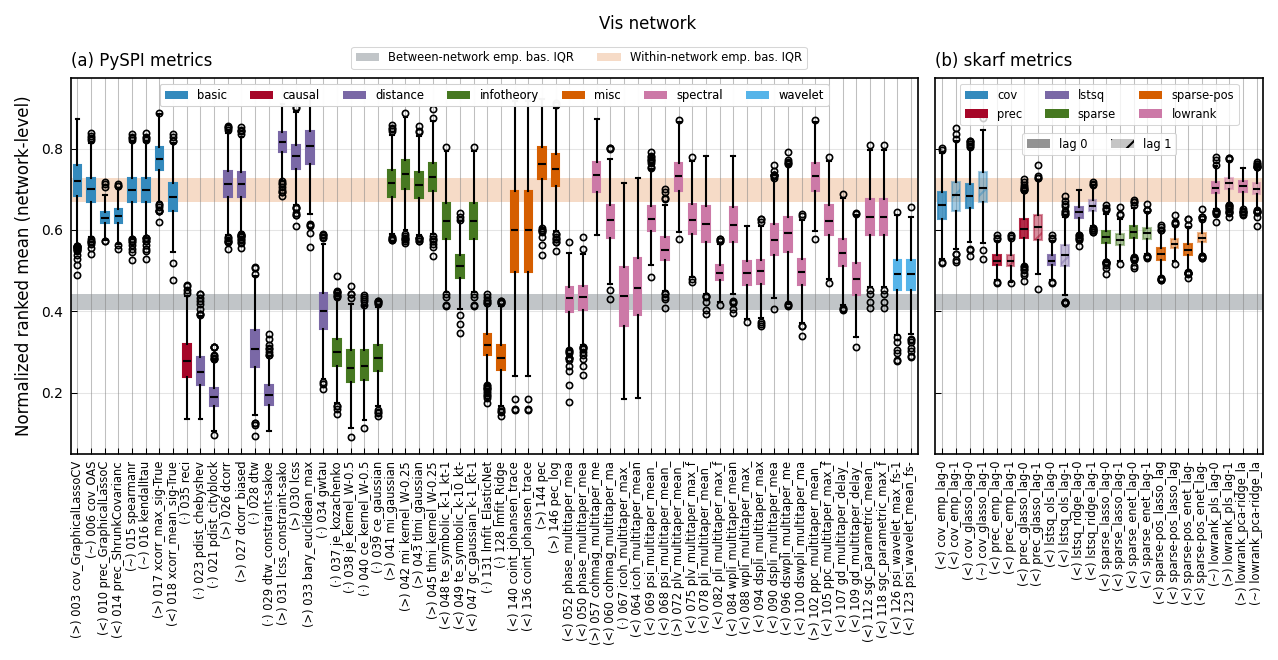

Rendering combined figure for SomMot.


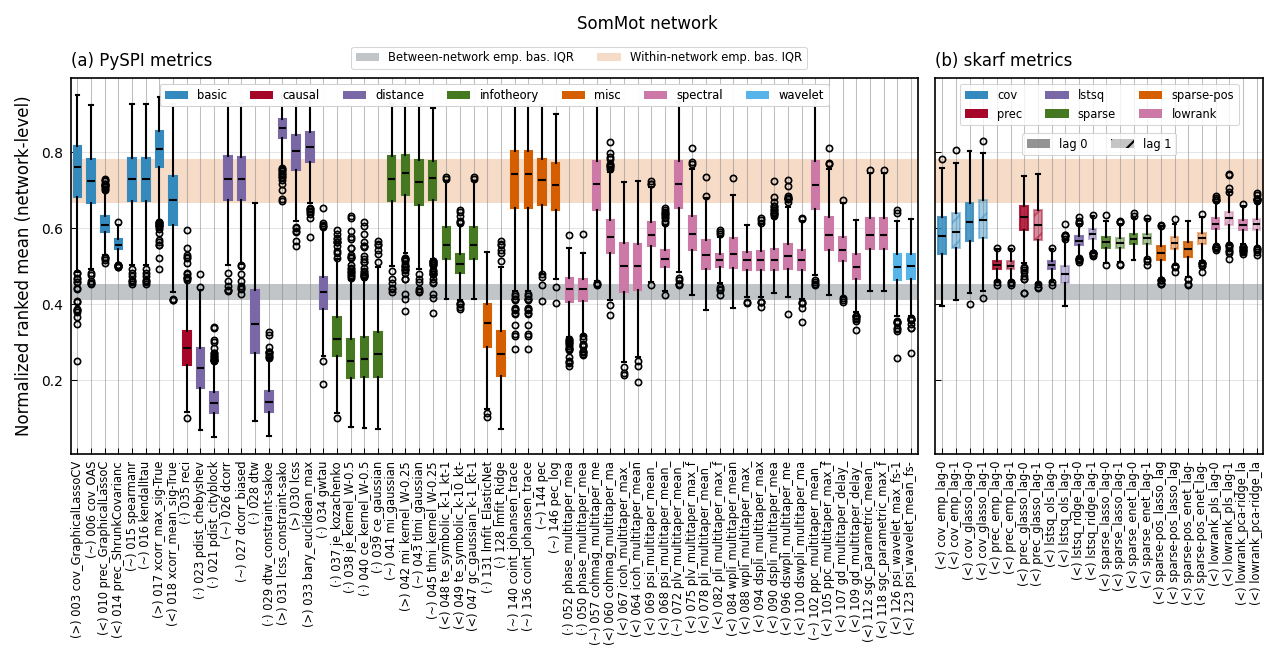

Rendering combined figure for DorsAttn.


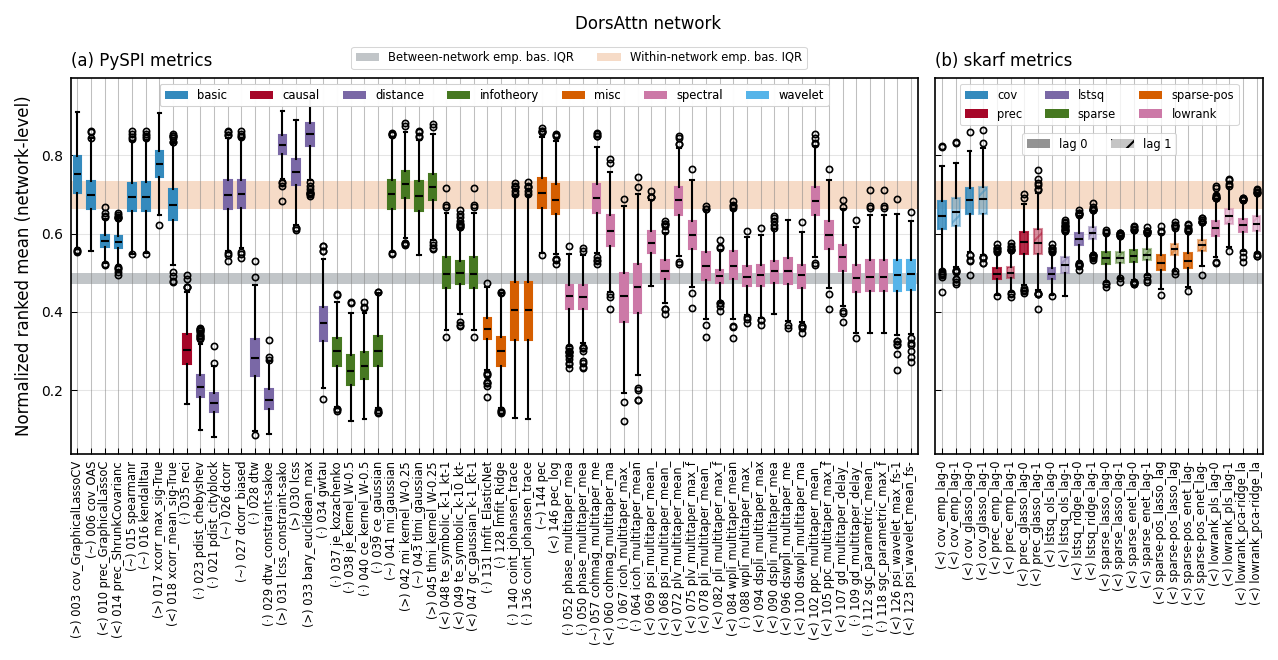

Rendering combined figure for SalVentAttn.


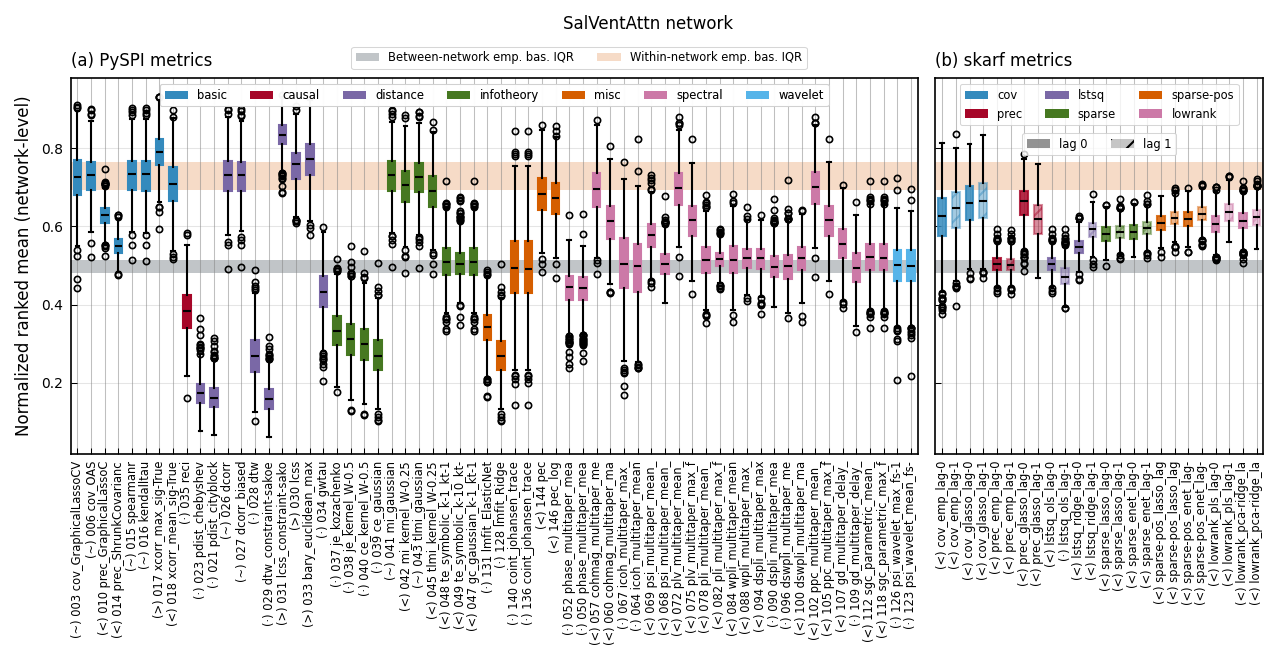

Rendering combined figure for Limbic.


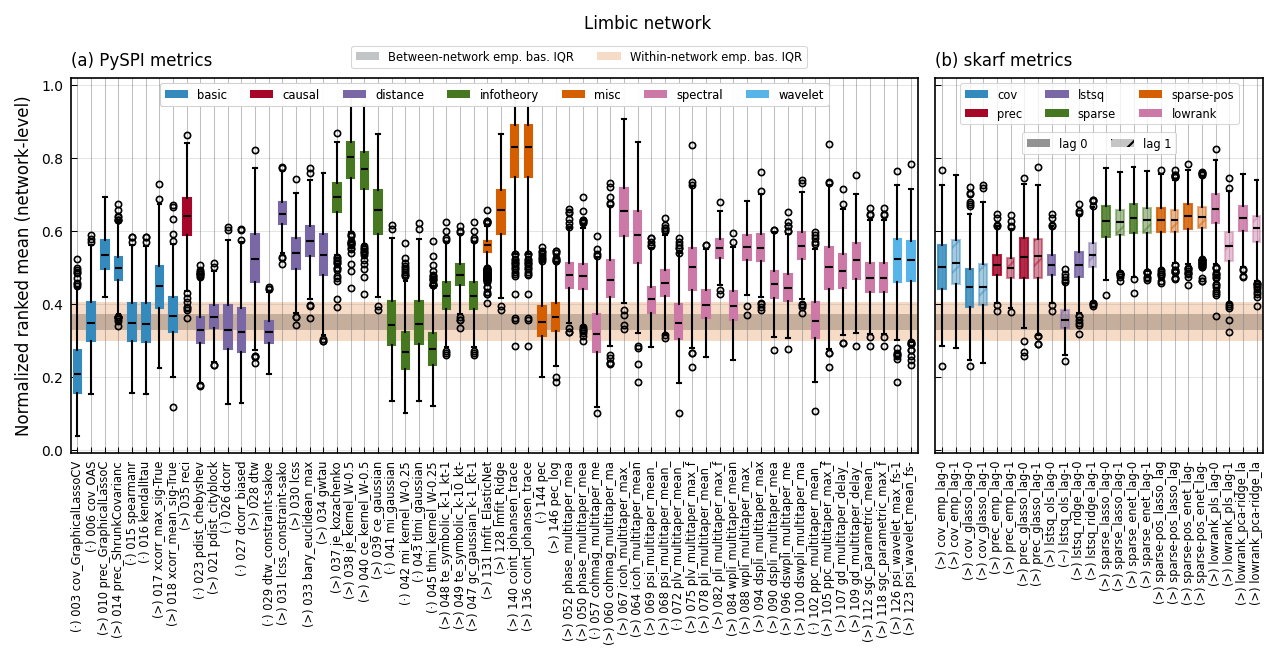

Rendering combined figure for Cont.


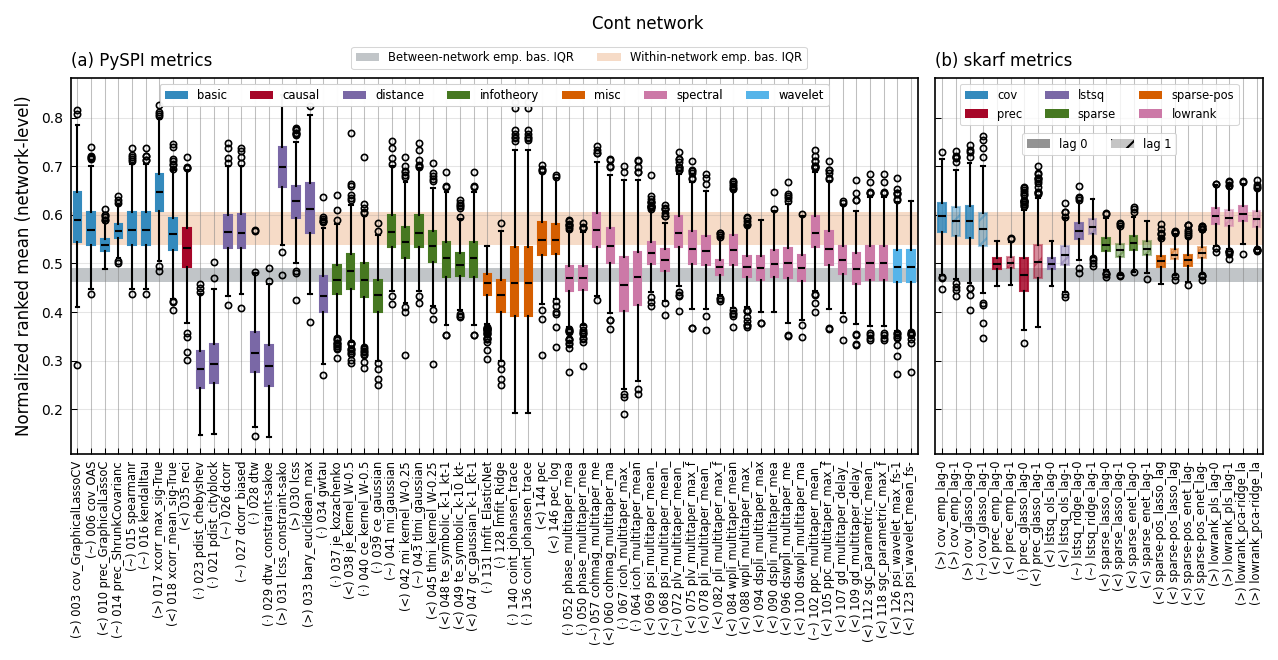

Rendering combined figure for Default.


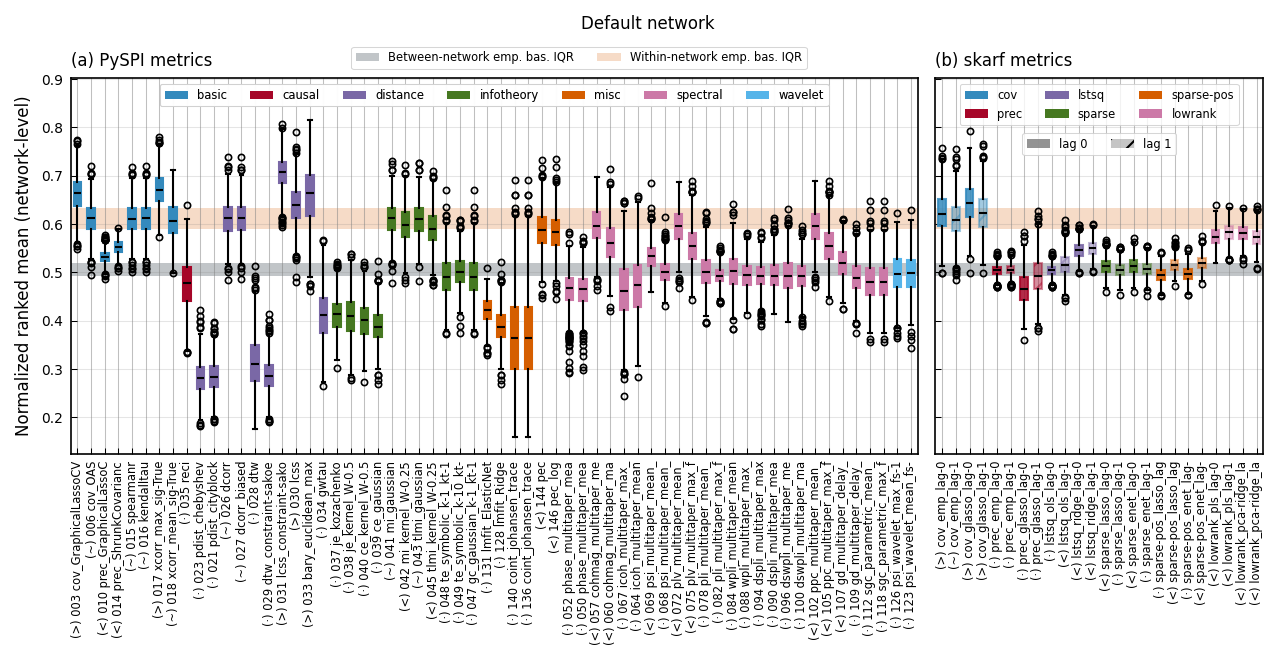

In [20]:
print("Using the same selected metric subset as the poster figure for network-level comparisons.")
print("Network order:", ", ".join(network_order))

network_pyspi_df = network_plot_df.query("method == 'pyspi'").copy()
network_pyspi_with_meta = spi_table.merge(
    network_pyspi_df.rename(columns={"func": "spi"}),
    on="spi",
    how="right",
)
network_pyspi_with_meta = network_pyspi_with_meta.dropna(subset=["spi"])
network_pyspi_with_meta["category"] = pd.Categorical(
    network_pyspi_with_meta["category"],
    categories=category_levels,
    ordered=True,
)

network_skarf_df = network_plot_df.query("method == 'skarf'").copy()
network_skarf_df["category"] = network_skarf_df["func"].map(func_category_map).fillna(
    network_skarf_df["func"].str.split("_").str[0]
)

network_reference_lookup = network_reference_summary_df.set_index("network")


def _network_subject_count(network):
    if "sub" not in network_plot_df.columns:
        return 0
    return int(network_plot_df.loc[network_plot_df["network"] == network, "sub"].nunique())


def _get_network_baseline_values(network):
    network_emp_cov = network_reference_df.loc[network_reference_df["network"] == network].copy()
    within_values = network_emp_cov[score_col].to_numpy(dtype=np.float64)
    within_values = within_values[np.isfinite(within_values)]
    between_values = network_emp_cov["between_network_reference_mean"].to_numpy(dtype=np.float64)
    between_values = between_values[np.isfinite(between_values)]
    return within_values, between_values


for network in network_order:
    print(f"Rendering combined figure for {network}.")
    within_values, between_values = _get_network_baseline_values(network)
    if len(within_values) == 0 or len(between_values) == 0:
        print(
            f"Skipping {network}: missing empirical-covariance baseline or between-network reference values."
        )
        continue

    network_emp_cov_median = float(np.nanmedian(within_values))
    row = network_reference_lookup.loc[network]

    left_width = max(len(pyspi_funcs), 1)
    right_width = max(len(skarf_func_order) * len(LAG_ORDER), 1)
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(3 * PLOTW, 0.95 * PLOTW),
        gridspec_kw={"width_ratios": [left_width, right_width]},
        sharey=True,
    )

    ax = axes[0]
    reference_handle = add_iqr_band(
        ax,
        row["between_q25"],
        row["between_q75"],
        REFERENCE_BAND_COLOR,
        REFERENCE_BAND_ALPHA,
        label="Between-network emp. bas. IQR",
    )
    emp_handle = add_iqr_band(
        ax,
        row["within_q25"],
        row["within_q75"],
        EMPIRICAL_COV_BAND_COLOR,
        EMPIRICAL_COV_BAND_ALPHA,
        label="Within-network emp. bas. IQR",
    )

    if pyspi_funcs:
        network_df = network_pyspi_with_meta.loc[network_pyspi_with_meta["network"] == network]
        pyspi_positions = np.arange(len(pyspi_funcs), dtype=np.float64)
        pyspi_data = [
            network_df.loc[network_df["spi"] == spi, score_col].to_numpy(dtype=np.float64)
            for spi in pyspi_funcs
        ]
        pyspi_box = ax.boxplot(
            pyspi_data,
            positions=pyspi_positions,
            widths=0.55,
            patch_artist=True,
            medianprops={"color": "k"},
        )
        for spi, patch in zip(pyspi_funcs, pyspi_box["boxes"]):
            category = pyspi_func_to_category.get(spi, "unknown")
            color = pyspi_category_colors.get(category, "#999999")
            patch.set_facecolor(color)
            patch.set_edgecolor(color)

        network_pyspi_labels = []
        pyspi_test_count = max(len(pyspi_funcs), 1)
        for spi in pyspi_funcs:
            vals = network_df.loc[network_df["spi"] == spi, score_col].to_numpy(dtype=np.float64)
            vals = vals[np.isfinite(vals)]
            reference_p = _safe_mwu_pvalue(vals, between_values, alternative="greater")
            baseline_p = _safe_mwu_pvalue(vals, within_values, alternative="two-sided")
            base_label = f"{spi_id_map.get(spi, 0):03d} {spi[:20]}"
            network_pyspi_labels.append(
                format_label(
                    base_label,
                    vals,
                    reference_p,
                    baseline_p,
                    pyspi_test_count,
                    network_emp_cov_median,
                )
            )

        ax.set_xticks(pyspi_positions)
        ax.set_xticklabels(network_pyspi_labels, rotation=90, fontsize="x-small")
    else:
        ax.set_xticks([])

    ax.set_title(f"(a) PySPI metrics", loc="left", fontsize="medium")
    ax.set_ylabel("Normalized ranked mean (network-level)", fontsize="medium")

    ref_handles = [handle for handle in [reference_handle, emp_handle] if handle is not None]
    if ref_handles:
        ref_legend = ax.legend(
            handles=ref_handles,
            loc="upper center",
            bbox_to_anchor=(0.6, 1.1),
            ncol=len(ref_handles),
            fontsize="x-small",
        )
        ax.add_artist(ref_legend)

    pyspi_cat_handles = [
        mpatches.Patch(facecolor=pyspi_category_colors[category], edgecolor="none", label=category)
        for category in pyspi_categories
    ]
    if pyspi_cat_handles:
        cat_legend = ax.legend(
            handles=pyspi_cat_handles,
            loc="upper center",
            ncol=max(len(pyspi_cat_handles), 1),
            fontsize="x-small",
        )
        ax.add_artist(cat_legend)

    ax = axes[1]
    add_iqr_band(
        ax,
        row["between_q25"],
        row["between_q75"],
        REFERENCE_BAND_COLOR,
        REFERENCE_BAND_ALPHA,
    )
    add_iqr_band(
        ax,
        row["within_q25"],
        row["within_q75"],
        EMPIRICAL_COV_BAND_COLOR,
        EMPIRICAL_COV_BAND_ALPHA,
    )

    if skarf_func_order:
        network_df = network_skarf_df.loc[network_skarf_df["network"] == network]
        combo_positions = {}
        xtick_positions = []
        xtick_labels = []

        skarf_test_count = max(len(skarf_func_order) * len(LAG_ORDER), 1)

        for func_idx, func in enumerate(skarf_func_order):
            for lag_idx, lag in enumerate(LAG_ORDER):
                pos = func_idx * len(LAG_ORDER) + lag_idx
                combo_positions[(func, lag)] = pos
                xtick_positions.append(pos)

                vals = network_df.loc[
                    (network_df["func"] == func) & (network_df["lag"] == lag),
                    score_col,
                ].to_numpy(dtype=np.float64)
                vals = vals[np.isfinite(vals)]
                reference_p = _safe_mwu_pvalue(vals, between_values, alternative="greater")
                baseline_p = _safe_mwu_pvalue(vals, within_values, alternative="two-sided")
                base = f"{func_display_names.get(func, func)}_lag-{lag}"[:20]
                xtick_labels.append(
                    format_label(
                        base,
                        vals,
                        reference_p,
                        baseline_p,
                        skarf_test_count,
                        network_emp_cov_median,
                    )
                )

        for lag in LAG_ORDER:
            lag_positions = np.array([combo_positions[(func, lag)] for func in skarf_func_order], dtype=np.float64)
            lag_data = []

            for func in skarf_func_order:
                vals = network_df.loc[
                    (network_df["func"] == func) & (network_df["lag"] == lag),
                    score_col,
                ].to_numpy(dtype=np.float64)
                vals = vals[np.isfinite(vals)]
                lag_data.append(vals if len(vals) else np.array([np.nan]))

            box = ax.boxplot(
                lag_data,
                positions=lag_positions,
                widths=0.55,
                patch_artist=True,
                medianprops={"color": "k"},
            )

            for func, patch in zip(skarf_func_order, box["boxes"]):
                category = func_category_map.get(func, "unknown")
                color = skarf_category_colors.get(category, "#999999")
                patch.set_facecolor(color)
                patch.set_edgecolor(color)
                patch.set_alpha(LAG_STYLES[lag]["alpha"])
                patch.set_hatch(LAG_STYLES[lag]["hatch"])

        ax.set_xticks(xtick_positions)
        ax.set_xticklabels(xtick_labels, rotation=90, fontsize="x-small")
    else:
        ax.set_xticks([])

    ax.set_title("(b) skarf metrics", loc="left", fontsize="medium")

    skarf_cat_handles = [
        mpatches.Patch(facecolor=skarf_category_colors[category], edgecolor="none", label=category)
        for category in skarf_categories
    ]
    lag_handles = [
        mpatches.Patch(
            facecolor="gray",
            alpha=LAG_STYLES[lag]["alpha"],
            hatch=LAG_STYLES[lag]["hatch"],
            label=f"lag {lag}",
        )
        for lag in LAG_ORDER
    ]
    if skarf_cat_handles:
        cat_legend = ax.legend(
            handles=skarf_cat_handles,
            loc="upper center",
            bbox_to_anchor=(0.5, 1),
            ncol=max(len(skarf_cat_handles) // 2, 1),
            fontsize="x-small",
        )
        ax.add_artist(cat_legend)
    if lag_handles:
        ax.legend(
            handles=lag_handles,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.87),
            ncol=len(lag_handles),
            fontsize="x-small",
        )

    for axis in axes:
        axis.grid(alpha=0.2, axis="y")

    fig.suptitle(f"{network} network", fontsize="medium", y=1.01)
    
    plt.subplots_adjust(wspace=0.03)
    plt.show()